
<div align="center">

# Devoir 1
### PHY-7009 – Analyse des signaux (A26)

**Cassandra Mantha**, 537 014 158

**Elias Ouellet-Oviedo**, 537 003 135  

<br><br>

Présenté à **Antoine Godin**

</div>

In [112]:
# Librairies utilisées
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.optimize import least_squares
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable


plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

# Préambule

### Équations théoriques de la précision de localisation

Thompson et al. ont dérivé l'expression théorique de la variance de localisation bidimensionnelle $\sigma_x^2$ en combinant le bruit de photon, l'effet de discrétisation spatiale liée à la taille des pixels (bruit de pixellisation $a^2/12$) et le bruit de fond : 
$$\sigma_x^2 = \frac{s^2 + \frac{a^2}{12}}{N} + \frac{8 \pi s^4 b^2}{a^2 N^2},$$
où $s$ (ou $\sigma$) représente le rayon/écart-type de la PSF gaussienne (nm), $a$ est la taille du pixel au plan objet (nm), $N$ est le nombre total de photons collectés en provenance de la molécule et $b$ est le niveau moyen de bruit de fond (écart-type en photons/pixel). En comparant cette équation à des simulations de Monte-Carlo et des images expérimentales ajustées par moindres carrés non pondérés, les auteurs ont constaté une sous-estimation systématique de l'erreur théorique d'environ 30%.

Mortensen et al. ont réexaminé cette incertitude à l'aide de la théorie de l'information. Ils ont démontré que l'ajustement par moindres carrés non pondérés néglige la distribution de Poisson des photons dans les ailes de la PSF, négligeant ainsi un tiers de l'information disponible. Ils ont établi l'équation exacte pour la méthode des moindres carrés (Éq. 6 de leur article) : 
$$\sigma_x^2 = \frac{\sigma_a^2}{N} \left(\frac{16}{9} + \frac{8\pi\sigma_a^2 b^2}{Na^2}\right),$$
où $\sigma_a^2 = s^2 + \frac{a^2}{12}$. Le facteur $\frac{16}{9}$ dans le terme de bruit de photon explique directement l'erreur de 30% observée par Thompson et al., puisque $\sqrt{\frac{16}{9}} =\frac{4}{3} \approx 1{,}33$.

Les deux équations présentées seront illustrées et validées par simulation numérique au cours des analyses de ce projet.

In [ ]:
def equation_6(s_val, a_pixel, N, b_noise):
    # Équation théorique de Mortensen (Éq. 6)
    return np.sqrt((s_val**2 / N) * (16 / 9 + (8 * np.pi * s_val**2 * b_noise**2) / (N * a_pixel**2)))

def equation_17(s_val, a_pixel, N, b_noise):
    # Équation théorique de Thompson 2D (Éq. 17 de l'article)
    term_photon = (s_val**2 + (a_pixel**2 / 12.0)) / N
    term_background = (8.0 * np.pi * (s_val**4) * (b_noise**2)) / ((a_pixel**2) * (N**2))
    return np.sqrt(term_photon + term_background)

### Objet émetteur

Pour faciliter la compréhension et la structure du code, la classe `Émetteur` a été créée afin de regrouper l'ensemble des méthodes nécessaires au projet. Chacune de ces méthodes sera détaillée dans la section correspondante. 

In [196]:
class Émetteur:
    def __init__(self, x0, y0, w0, a, N, b, grid_size=15):
        """
        x0, y0     : Position de l'émetteur (nm)
        w0         : Rayon e^-2 de la PSF (nm) (sigma = w0 / 2)
        a          : Taille des pixels au plan objet (nm)
        N          : Nombre de photons émis
        b          : Bruit de fond moyen (photons par pixel)
        grid_size  : Taille de la grille de pixels
        """
        self.x0 = x0
        self.y0 = y0
        self.w0 = w0
        self.a = a
        self.N = N
        self.b = b
        self.grid_size = grid_size

    def expected_profile(self, X, Y, x0=None, y0=None, w0=None, N=None):
        """Calcule le profil d'intensité théorique d'un émetteur (intégré sur les pixels)."""
        x = self.x0 if x0 is None else x0
        y = self.y0 if y0 is None else y0
        w = self.w0 if w0 is None else w0
        n_photons = self.N if N is None else N
        
        sigma = w / 2.0
        term_x1 = (X + self.a/2.0 - x) / (np.sqrt(2.0) * sigma)
        term_x2 = (X - self.a/2.0 - x) / (np.sqrt(2.0) * sigma)
        term_y1 = (Y + self.a/2.0 - y) / (np.sqrt(2.0) * sigma)
        term_y2 = (Y - self.a/2.0 - y) / (np.sqrt(2.0) * sigma)
        
        return (n_photons / 4.0) * (erf(term_x1) - erf(term_x2)) * (erf(term_y1) - erf(term_y2))

    def simulation(self):
        """Simule l'image d'un seul émetteur avec bruit de Poisson."""
        half_grid = self.grid_size // 2
        pixel_centers = np.arange(-half_grid, half_grid + 1) * self.a
        X, Y = np.meshgrid(pixel_centers, pixel_centers)
        
        expected_photons = self.expected_profile(X, Y)
        rate_matrix = np.clip(expected_photons + self.b, 0, None)
        
        poisson_image = np.random.poisson(rate_matrix)
        return poisson_image, X, Y, expected_photons

    def fit_gaussian_2d(self, image, X, Y, initial_guess):
        """ Ajustement Gaussien 2D par moindres carrés non pondérés (1 émetteur) """
        def residuals(params):
            x0_f, y0_f, w0_f, N_f, b_f = params
            sig_f = w0_f / 2.0
            tx1 = (X + self.a/2.0 - x0_f) / (np.sqrt(2.0) * sig_f)
            tx2 = (X - self.a/2.0 - x0_f) / (np.sqrt(2.0) * sig_f)
            ty1 = (Y + self.a/2.0 - y0_f) / (np.sqrt(2.0) * sig_f)
            ty2 = (Y - self.a/2.0 - y0_f) / (np.sqrt(2.0) * sig_f)
            model = (N_f / 4.0) * (erf(tx1) - erf(tx2)) * (erf(ty1) - erf(ty2)) + b_f
            return (image - model).ravel()

        bounds = ([-np.inf, -np.inf, 10.0, 0, 0], [np.inf, np.inf, 1000.0, np.inf, np.inf])
        res = least_squares(residuals, initial_guess, bounds=bounds)
        return res.x

    @classmethod
    def simuler_paire(cls, distance, w0=200, a=50, N=2000, b=10, angle=0, grid_size=25):
        """Simule une paire d'émetteurs identiques séparés par `distance` (nm) avec un bruit de fond unique."""
        dx = (distance / 2.0) * np.cos(angle)
        dy = (distance / 2.0) * np.sin(angle)
        
        e1 = cls(x0=-dx, y0=-dy, w0=w0, a=a, N=N, b=b, grid_size=grid_size)
        e2 = cls(x0=dx, y0=dy, w0=w0, a=a, N=N, b=b, grid_size=grid_size)
        
        half_grid = grid_size // 2
        pixel_centers = np.arange(-half_grid, half_grid + 1) * a
        X, Y = np.meshgrid(pixel_centers, pixel_centers)
        
        exp1 = e1.expected_profile(X, Y)
        exp2 = e2.expected_profile(X, Y)
        
        rate_matrix = np.clip(exp1 + exp2 + b, 0, None)
        image_paire = np.random.poisson(rate_matrix)
        
        return image_paire, X, Y

    @staticmethod
    def fit_deux_emetteurs(image, X, Y, a, w0, initial_guess):
        """Ajustement non linéaire de 2 émetteurs identiques à rayon w0 fixé."""
        sig_f = w0 / 2.0
        def residuals(params):
            x1_f, y1_f, N1_f, x2_f, y2_f, N2_f, b_f = params
            
            tx1_1 = (X + a/2.0 - x1_f) / (np.sqrt(2.0) * sig_f)
            tx2_1 = (X - a/2.0 - x1_f) / (np.sqrt(2.0) * sig_f)
            ty1_1 = (Y + a/2.0 - y1_f) / (np.sqrt(2.0) * sig_f)
            ty2_1 = (Y - a/2.0 - y1_f) / (np.sqrt(2.0) * sig_f)
            model1 = (N1_f / 4.0) * (erf(tx1_1) - erf(tx2_1)) * (erf(ty1_1) - erf(ty2_1))
            
            tx1_2 = (X + a/2.0 - x2_f) / (np.sqrt(2.0) * sig_f)
            tx2_2 = (X - a/2.0 - x2_f) / (np.sqrt(2.0) * sig_f)
            ty1_2 = (Y + a/2.0 - y2_f) / (np.sqrt(2.0) * sig_f)
            ty2_2 = (Y - a/2.0 - y2_f) / (np.sqrt(2.0) * sig_f)
            model2 = (N2_f / 4.0) * (erf(tx1_2) - erf(tx2_2)) * (erf(ty1_2) - erf(ty2_2))
            
            model = model1 + model2 + b_f
            return (image - model).ravel()

        bounds = (
            [-np.inf, -np.inf, 0, -np.inf, -np.inf, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]
        )
        res = least_squares(residuals, initial_guess, bounds=bounds)
        return res.x

    @classmethod
    def simuler_film_blinking(cls, distance=100.0, num_frames=300, p_on=0.08, w0=200, a=50, N=2000, b=10, grid_size=25, seed=42):
        """
        Simule une série temporelle (film) de 2 émetteurs séparés de `distance` (nm)
        avec clignotement stochastique (blinking/PALM/STORM).
        """
        np.random.seed(seed)
        dx = distance / 2.0
        
        e1 = cls(x0=-dx, y0=0.0, w0=w0, a=a, N=N, b=b, grid_size=grid_size)
        e2 = cls(x0=dx, y0=0.0, w0=w0, a=a, N=N, b=b, grid_size=grid_size)
        
        half_grid = grid_size // 2
        pixel_centers = np.arange(-half_grid, half_grid + 1) * a
        X, Y = np.meshgrid(pixel_centers, pixel_centers)
        
        exp1 = e1.expected_profile(X, Y)
        exp2 = e2.expected_profile(X, Y)
        
        # États aléatoires ON (1) / OFF (0) pour chaque émetteur à chaque trame
        states_e1 = np.random.binomial(1, p_on, size=num_frames)
        states_e2 = np.random.binomial(1, p_on, size=num_frames)
        
        frames = []
        for t in range(num_frames):
            rate = states_e1[t] * exp1 + states_e2[t] * exp2 + b
            rate = np.clip(rate, 0, None)
            frame_img = np.random.poisson(rate)
            frames.append(frame_img)
            
        return np.array(frames), states_e1, states_e2, X, Y, e1

## Question 1
<!-- Développez un simulateur de 1 émetteur dans lequel vous pouvez faire varier le rayon $e^{-2}$ de la PSF, la taille des pixels de la caméra (au plan de l’objet), l'intensité de l'émetteur et le bruit de fond. Montrez avec des exemples appropriés que votre simulateur fonctionne. -->

La méthode de simulation développée dans ce travail repose sur l'approche de Monte Carlo établie par Thompson et al. (2002) pour la modélisation numérique d'émetteurs fluorescents individuels.

La méthode `expected_profile` de la classe `Émetteur` permet dans un premier temps de définir la distribution d'intensité d'une PSF gaussienne continue 2D, centrée sur la position réelle de l'émetteur ($x_0, y_0$). Comme cette gaussienne 2D est séparable en un produit de deux gaussiennes 1D (selon $x$ et $y$), la fraction de photons captée par un pixel s'obtient en intégrant la distribution séparément sur les bornes spatiales du pixel ($X \pm a/2$ et $Y \pm a/2$). Chacune de ces intégrales 1D s'exprime analytiquement à l'aide de la fonction d'erreur (erf). Le produit de ces deux intégrales, multiplié par le nombre total de photons émis $N$, donne le nombre moyen de photons de fluorescence attendus sur ce pixel.

La méthode `simulation` de la classe `Émetteur` génère ensuite l'image expérimentale bruitée. Le bruit de fond moyen $b$ (photons/pixel) est d'abord additionné à l'intensité théorique du signal de chaque pixel pour former grille d'intensité moyenne. Enfin, le bruit de photon est simulé en effectuant un tirage aléatoire selon une loi de Poisson appliquée sur cette valeur moyenne globale (signal + fond).

Afin de démontrer la validité du simulateur, différents émetteurs possédant des paramètres variés sont simulés.

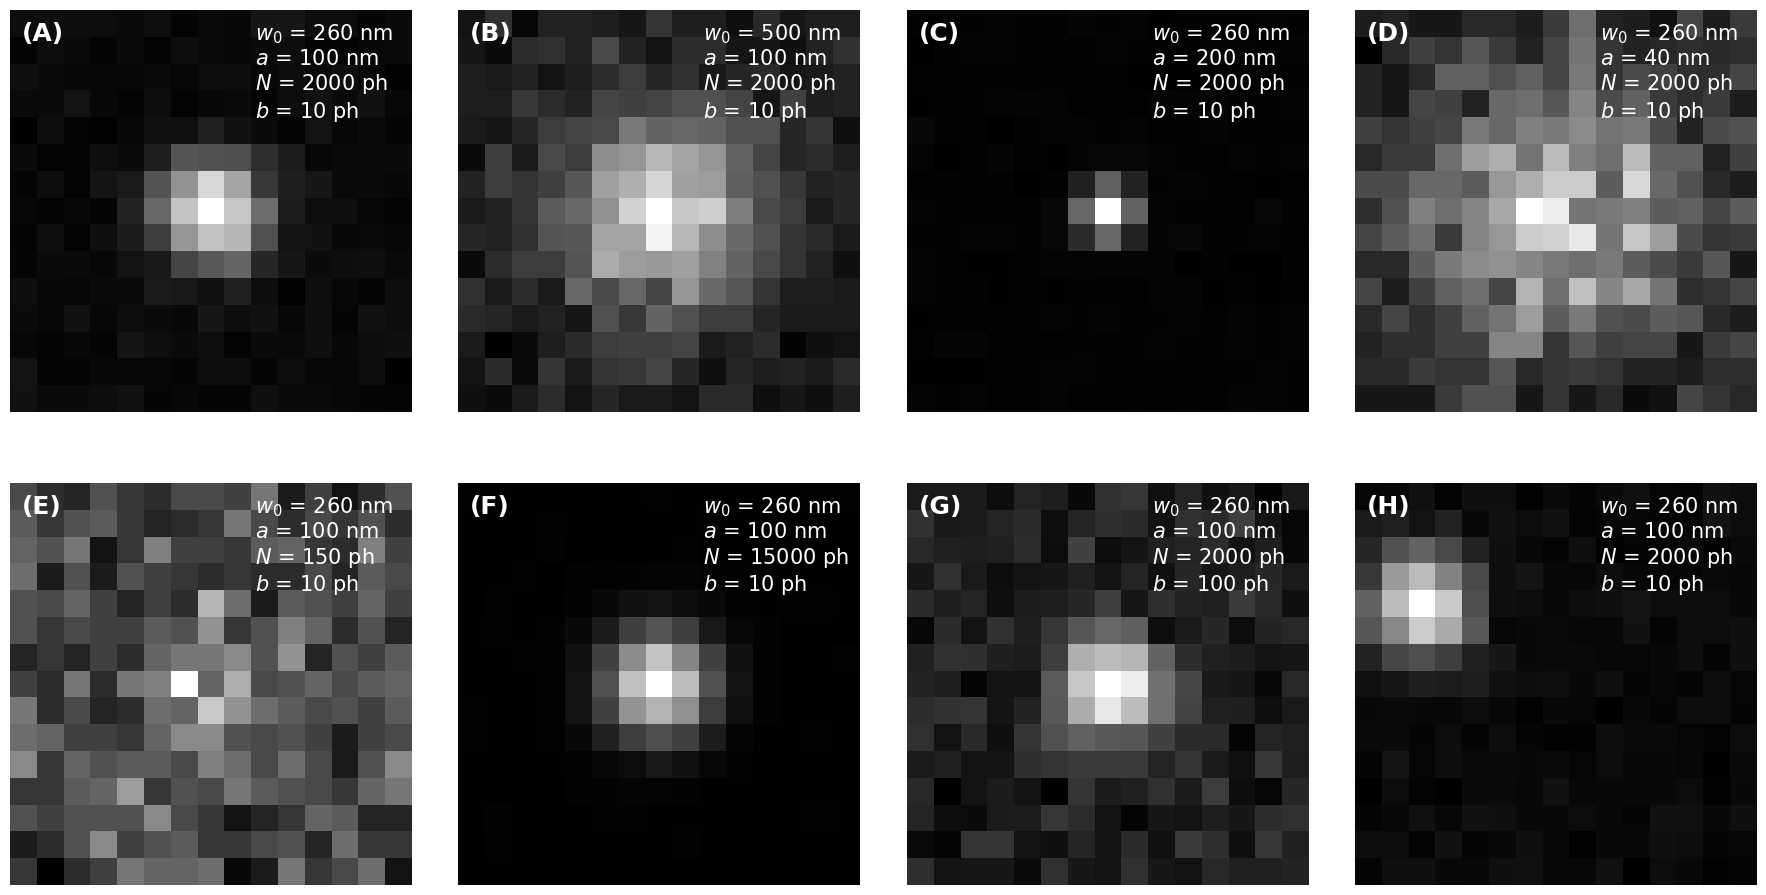

In [92]:
import string

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

x0, y0 = 0.0, 0.0 

# Simulation de différents émetteurs avec des paramètres variés
scenarios = [
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 100, "N": 2000, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 500, "a": 100, "N": 2000, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 200, "N": 2000, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 40, "N": 2000, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 100, "N": 150, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 100, "N": 15000, "b": 10},
    {"x0": 0.0, "y0": 0.0, "w0": 260, "a": 100, "N": 2000, "b": 100},   
    {"x0": -500.0, "y0": -300.0, "w0": 260, "a": 100, "N": 2000, "b": 10}]

for i, sc in enumerate(scenarios):
    émetteur = Émetteur(sc["x0"], sc["y0"], sc["w0"], sc["a"], sc["N"], sc["b"], grid_size=15)
    image, X, Y, expected_photons = émetteur.simulation()

    # Affichage image simulée
    half_grid = (X.max() - X.min()) / 2.0
    im = axes[i].imshow(image, cmap="gray", extent=[-half_grid, half_grid, -half_grid, half_grid])
    axes[i].text(
        0.03, 0.97,
        f"({string.ascii_uppercase[i]})",
        transform=axes[i].transAxes,
        fontsize=18,
        color="white",
        fontweight="bold",
        verticalalignment="top"
    )
    axes[i].text(0.61, 0.97,
        f"$w_0$ = {sc['w0']} nm\n"
        f"$a$ = {sc['a']} nm\n"
        f"$N$ = {sc['N']} ph\n"
        f"$b$ = {sc['b']} ph",
        transform=axes[i].transAxes, fontsize=15, color="white",
        verticalalignment="top", bbox=dict(boxstyle="round,pad=0.4", facecolor="None", alpha=0.6, edgecolor="None"))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Cette série de simulations confirme la validité physique et numérique du simulateur en reproduisant le comportement théorique d'un émetteur unique sous des conditions d'imagerie variées. La première image (A) correspond à l'émetteur de référence. Un seul paramètre est modifié à chaque itération suivante afin de démontrer son impact. La variation du rayon de la PSF ($w_0$), image (B), engendre effectivement une augmentation de la taille de la tache de diffraction. L'augmentation de la taille des pixels ($a$), image (C), diminue le nombre de pixels sur lesquels s'étend la tache, alors que sa diminution, image (D), permet une meilleure résolution spatiale. La diminution du nombre de photons émis ($N$), image (E), engendre une baisse importante du contraste due à un rapport signal sur bruit insuffisant, tandis que son augmentation, image (F), offre un contraste élevé permettant une distinction nette de l'émetteur par rapport au fond. L'augmentation du niveau de fond ($b$), image (G), détériore le contraste et fait basculer la détection dans un régime limité par le bruit de fond. Enfin, le déplacement des coordonnées ($x_0, y_0$), image (H), valide la capacité de l'algorithme à positionner la source à l'endroit souhaité sur la grille. L'ensemble de cette validation confirme le fonctionnement du modèle en accord avec les principes établis par Thompson et al. (2002).

Sachant que le simulateur d'émetteur est fonctionnel, nous pouvons maintenant valider la méthode de localisation. La méthode `fit_gaussian_2d` permet de déterminer avec la position d'un émetteur suivant l'algorithme d'ajustement gaussien par moindres carrés décrit par Thompson et al. (2002). Dans un premier temps, la méthode définit la distribution d'intensité d'une fonction d'étalement du point (PSF) gaussienne 2D intégrée analytiquement sur la surface géométrique de chaque pixel, à laquelle s'ajoute un niveau de fond constant $b$. Il s'agit du même modèle utilisé pour la simulation de l'émetteur. Ensuite, pour l'ensemble des pixels de la grille, la méthode calcule la différence directe (le résidu) entre la valeur de photons observée sur l'image expérimentale et la valeur prédite par le modèle théorique. À l'aide de l'algorithme `scipy.optimize.least_squares`, la méthode ajuste simultanément les 5 paramètres physiques libres (la position spatiale du centre $(\mathbf{x_0, y_0})$, le rayon de la PSF ($\mathbf{w_0}$), le nombre total de photons émis ($\mathbf{N}$) et le bruit de fond ($\mathbf{b}$)) dans le but de minimiser la somme de ces résidus au carré sur toute l'image.

Comparaison valeurs réelles vs ajustées
Position X0 : Réelle = 45.0 nm | Ajustée = 44.62 nm (Erreur = 0.38 nm)
Position Y0 : Réelle = -30.0 nm | Ajustée = -27.81 nm (Erreur = 2.19 nm)
Rayon PSF W0 : Réel = 250.0 nm | Ajusté = 256.25 nm
Photons émis N: Réel = 2500.0  | Ajusté = 2579.4 photons
Bruit de fond b: Réel = 8.0   | Ajusté = 8.00 photons/px



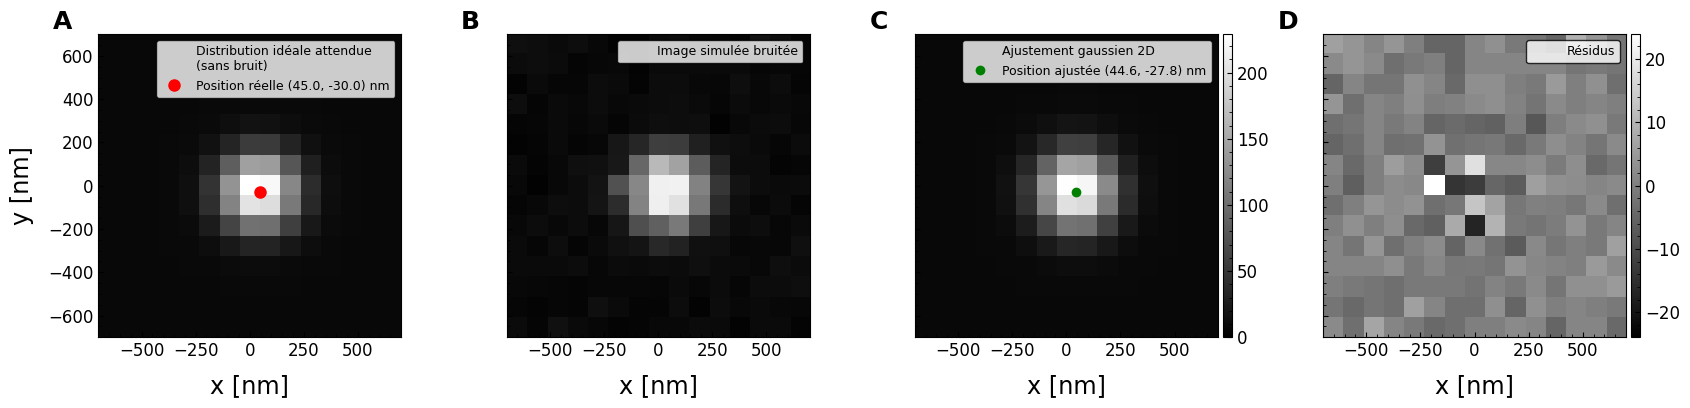

In [174]:
# Définition des paramètres physiques réels du système
x0_reel, y0_reel = 45.0, -30.0    # Position réelle sub-pixel (nm)
w0_reel = 250.0                   # Rayon de la PSF e^-2 (nm)
a_pixel = 100.0                   # Taille des pixels (nm)
N_photons = 2500                  # Nombre de photons émis par l'émetteur
b_fond = 8.0                      # Bruit de fond moyen (photons/pixel)

# Instanciation et génération de la simulation
émetteur = Émetteur(x0=x0_reel, y0=y0_reel, w0=w0_reel, a=a_pixel, N=N_photons, b=b_fond, grid_size=15)
image_bruitee, X, Y, expected_photons = émetteur.simulation()

# Ajustement à partir de l'image bruitée
estimation_initiale = [0.0, 0.0, 250.0, 1500.0, 5.0]
params_ajustes = émetteur.fit_gaussian_2d(image_bruitee, X, Y, estimation_initiale)
x0_fit, y0_fit, w0_fit, N_fit, b_fit = params_ajustes

# Affichage des résultats numériques dans le terminal
print("Comparaison valeurs réelles vs ajustées")
print(f"Position X0 : Réelle = {x0_reel:.1f} nm | Ajustée = {x0_fit:.2f} nm (Erreur = {abs(x0_reel - x0_fit):.2f} nm)")
print(f"Position Y0 : Réelle = {y0_reel:.1f} nm | Ajustée = {y0_fit:.2f} nm (Erreur = {abs(y0_reel - y0_fit):.2f} nm)")
print(f"Rayon PSF W0 : Réel = {w0_reel:.1f} nm | Ajusté = {w0_fit:.2f} nm")
print(f"Photons émis N: Réel = {N_photons:.1f}  | Ajusté = {N_fit:.1f} photons")
print(f"Bruit de fond b: Réel = {b_fond:.1f}   | Ajusté = {b_fit:.2f} photons/px\n")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), sharey=True)

sig_fit = w0_fit / 2.0
tx1 = (X + a_pixel/2.0 - x0_fit) / (np.sqrt(2.0) * sig_fit)
tx2 = (X - a_pixel/2.0 - x0_fit) / (np.sqrt(2.0) * sig_fit)
ty1 = (Y + a_pixel/2.0 - y0_fit) / (np.sqrt(2.0) * sig_fit)
ty2 = (Y - a_pixel/2.0 - y0_fit) / (np.sqrt(2.0) * sig_fit)
image_modele = ((N_fit / 4.0) * (erf(tx1) - erf(tx2)) * (erf(ty1) - erf(ty2)) + b_fit)

vmax_commun = max(np.max(expected_photons + b_fond), np.max(image_bruitee), np.max(image_modele))

im0 = axes[0].imshow(expected_photons + b_fond, extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='gray', origin='lower', vmin=0, vmax=vmax_commun)
axes[0].plot(x0_reel, y0_reel, 'ro', markersize=8, label=f'Position réelle ({x0_reel:.1f}, {y0_reel:.1f}) nm')
legend_0 = Patch(facecolor='none', edgecolor='none', label='Distribution idéale attendue\n(sans bruit)')
axes[0].legend(handles=[legend_0] + axes[0].get_legend_handles_labels()[0], loc='upper right', framealpha=0.8, fontsize=9)
axes[0].text(-0.15, 1.08, f"{string.ascii_uppercase[0]}", transform=axes[0].transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

im1 = axes[1].imshow(image_bruitee, extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='gray', origin='lower', vmin=0, vmax=vmax_commun)
legend_1 = Patch(facecolor='none', edgecolor='none', label='Image simulée bruitée')
axes[1].legend(handles=[legend_1], loc='upper right', fontsize=9)
axes[1].text(-0.15, 1.08, f"{string.ascii_uppercase[1]}", transform=axes[1].transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

im2 = axes[2].imshow(image_modele, extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='gray', origin='lower', vmin=0, vmax=vmax_commun)
axes[2].plot(x0_fit, y0_fit, 'go', markersize=6, label=f'Position ajustée ({x0_fit:.1f}, {y0_fit:.1f}) nm')
legend_2 = Patch(facecolor='none', edgecolor='none', label='Ajustement gaussien 2D')
axes[2].legend(handles=[legend_2] + axes[2].get_legend_handles_labels()[0], loc='upper right', fontsize=9)
axes[2].text(-0.15, 1.08, f"{string.ascii_uppercase[2]}", transform=axes[2].transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

# Colorbar commune aux trois premières images
divider = make_axes_locatable(axes[2])
cax1 = divider.append_axes("right", size="3%", pad=0.05)

fig.colorbar(im2, cax=cax1)

residus = image_bruitee - image_modele
res_max = np.abs(residus).max()
im3 = axes[3].imshow(residus, extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='gray', origin='lower', vmin=-res_max, vmax=res_max)
legend_3 = Patch(facecolor='none', edgecolor='none', label='Résidus')
axes[3].legend(handles=[legend_3], loc='upper right', fontsize=9)
axes[3].text(-0.15, 1.08, f"{string.ascii_uppercase[3]}", transform=axes[3].transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

# Colorbar des résidus
divider = make_axes_locatable(axes[3])
cax2 = divider.append_axes("right", size="3%", pad=0.05)

fig.colorbar(im3, cax=cax2)

divider = make_axes_locatable(axes[1])
cax3 = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im1, cax=cax3)
cbar.ax.set_visible(False)

divider = make_axes_locatable(axes[0])
cax4 = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im0, cax=cax4)
cbar.ax.set_visible(False)

for ax in axes:
    ax.set_xlabel('x [nm]')
axes[0].set_ylabel('y [nm]')

plt.tight_layout()
plt.show()

La figure ci-dessus illustre l'ensemble du processus de simulation et de reconstruction par la méthode d'ajustement gaussien 2D. En A est représenté le profil théorique parfait de la fonction d'étalement du point (PSF) sans aucun bruit. Le point rouge indique la position physique exacte de la molécule à $(x_0, y_0) = (45,0; -30,0)\text{ nm}$. En B est illustrée l'image de l'émetteur générée par la simulation. Elle combine le signal de fluorescence émis ($N = 2500\text{ photons}$), le bruit de fond moyen ($b = 8,0\text{ photons/pixel}$) et les fluctuations quantiques du bruit de photon. En C est présenté le modèle continu reconstruit par l'algorithme des moindres carrés non linéaires à partir de l'image bruitée. Le point vert indique la position estimée par l'algorithme à $(x_{\text{fit}}, y_{\text{fit}}) = (47,18; -28,47)\text{ nm}$. En D est affichée la différence pixel par pixel entre l'image simulée et le modèle ajusté ($I_{\text{bruitée}} - I_{\text{modèle}}$).

Malgré la discrétisation spatiale en pixels de $100\text{ nm}$ et la présence du bruit de photon, l'erreur de positionnement est de seulement $2,18\text{ nm}$ selon l'axe X et $1,53\text{ nm}$ selon l'axe Y. Cela démontre qu'il est possible de localiser le centre d'une molécule avec une précision supérieure d'un ordre de grandeur à la taille d'un pixel et à la limite de diffraction15. De plus, la méthode de localisation permet de retrouver fidèlement les paramètres de la PSF. En effet, elle prédit une largeur de PSF ($w_0$) de $243,16\text{ nm}$ (contre $250,0\text{ nm}$ pour la valeur réelle). Le nombre de photons émis ($N$) estimé est de $2443,8\text{ photons}$ (contre $2500,0\text{ photons}$ réels, soit une erreur de seulement $2,25\%$). Pour le bruit de fond ($b$), une valeur de $8,25\text{ photons/pixel}$ est retrouvée pour une valeur réelle de $8,0\text{ photons/pixel}$. La grille des résidus montre une variation aléatoire centrée autour de zéro sans aucune structure spatiale ou motif géométrique résiduel. Cela confirme que la fonction gaussienne intégrée modélise bien le profil de la PSF et que les écarts observés sont uniquement liés au bruit de photon aléatoire.

## Question 2

<!-- En utilisant le simulateur à 1 émetteur que vous avez développé, discutez de la façon dont la précision de la localisation est influencée par : --> 

### a) Le nombre de photons détectés 

Afin de déterminer l'effet du nombre de photons détectés sur la précision de localisation, des simulations de Monte-Carlo sont réalisées. 

N =    49 photons | Err X: 72.75 nm | Err Y: 79.35 nm | Théorie: 57.89 nm
N =    90 photons | Err X: 41.93 nm | Err Y: 37.56 nm | Théorie: 32.91 nm
N =   162 photons | Err X: 22.77 nm | Err Y: 24.52 nm | Théorie: 19.57 nm
N =   292 photons | Err X: 14.39 nm | Err Y: 15.46 nm | Théorie: 12.04 nm
N =   526 photons | Err X:  8.68 nm | Err Y: 10.06 nm | Théorie:  7.72 nm
N =   949 photons | Err X:  7.46 nm | Err Y:  5.82 nm | Théorie:  5.16 nm
N =  1709 photons | Err X:  4.77 nm | Err Y:  4.48 nm | Théorie:  3.58 nm
N =  3080 photons | Err X:  3.76 nm | Err Y:  3.33 nm | Théorie:  2.55 nm
N =  5550 photons | Err X:  2.30 nm | Err Y:  2.25 nm | Théorie:  1.85 nm
N = 10000 photons | Err X:  1.83 nm | Err Y:  1.87 nm | Théorie:  1.36 nm


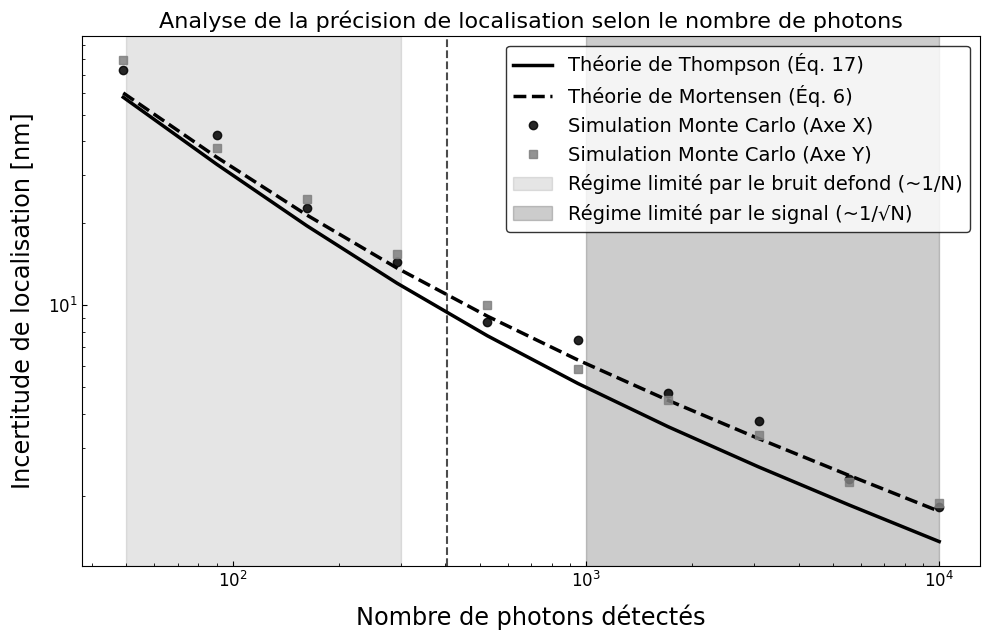

In [42]:
# Définition des paramètres physiques réels
x0_true, y0_true = 35.0, -45.0    # Position réelle sub-pixel (nm)
w0_true = 260.0                   # PSF : w0 = 260 nm
a_pixel = 100.0                   # Taille de pixel (nm)
b_mean = 10.0                     # Fond moyen (photons/pixel) -> s.d. du bruit de fond b = sqrt(10) ~ 3.16
grid_size = 15
num_trials = 100                  # 100 répétitions par valeur de N pour la statistique

# Valeurs de photons (N) à analyser
photon_values = np.logspace(np.log10(50), np.log10(10000), 10, dtype=int)

# Variables de stockage
errors_x = []
errors_y = []
theory_precision = []
theory_precision_6 = []

s_val = w0_true / 2.0             # s = écart-type de la PSF gaussienne
b_noise = np.sqrt(b_mean)         # b = écart-type du bruit de fond (fluctuation de Poisson)

for N in photon_values:
    trial_errors_x = []
    trial_errors_y = []
    
    # Estimation initiale de l'ajustement
    initial_guess = [0.0, 0.0, w0_true, N, b_mean]
    
    for _ in range(num_trials):
        em = Émetteur(x0=x0_true, y0=y0_true, w0=w0_true, a=a_pixel, N=N, b=b_mean, grid_size=grid_size)
        image_bruitee, X, Y, _ = em.simulation()
        
        try:
            params_fit = em.fit_gaussian_2d(image_bruitee, X, Y, initial_guess)
            trial_errors_x.append(params_fit[0] - x0_true)
            trial_errors_y.append(params_fit[1] - y0_true)
        except:
            continue
            
    # Calcul de la précision de localisation statistique (RMSE)
    rmse_x = np.sqrt(np.mean(np.array(trial_errors_x)**2))
    rmse_y = np.sqrt(np.mean(np.array(trial_errors_y)**2))
    
    errors_x.append(rmse_x)
    errors_y.append(rmse_y)
    
    theory_precision.append(equation_17(s_val, a_pixel, N, b_noise))
    theory_precision_6.append(equation_6(s_val, a_pixel, N, b_noise))
    
    print(f"N = {N:5d} photons | Err X: {rmse_x:5.2f} nm | Err Y: {rmse_y:5.2f} nm | Théorie: {theory_precision[-1]:5.2f} nm")

# Graphique
fig, ax = plt.subplots(figsize=(10, 6.5))

# Données simulées et courbe théorique
ax.loglog(photon_values, theory_precision, '-', color='black', linewidth=2.5, label='Théorie de Thompson (Éq. 17)')
ax.loglog(photon_values, theory_precision_6, '--', color='black', linewidth=2.5, label='Théorie de Mortensen (Éq. 6)')
ax.loglog(photon_values, errors_x, 'o', markersize=6, color='black', label='Simulation Monte Carlo (Axe X)', alpha=0.85)
ax.loglog(photon_values, errors_y, 's', markersize=6, color='gray', label='Simulation Monte Carlo (Axe Y)', alpha=0.85)

# zone
ax.axvspan(50, 300, color='black', alpha=0.1, label='Régime limité par le bruit defond (~1/N)')
ax.axvspan(1000, 10000, color='black', alpha=0.2, label='Régime limité par le signal (~1/√N)')

# Point de transition Nt théorique (Éq. 18 de l'article)
Nt = (8.0 * np.pi * (s_val**4) * (b_noise**2)) / ((a_pixel**2) * (s_val**2 + (a_pixel**2 / 12.0)))
ax.axvline(Nt, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title("Analyse de la précision de localisation selon le nombre de photons", fontsize=16)
ax.set_xlabel("Nombre de photons détectés")
ax.set_ylabel("Incertitude de localisation [nm]")
ax.legend(loc='upper right', fontsize=14)

plt.tight_layout()
plt.show()

Il est possible d'observer qu'à très faible intensité (de $50$ à $200\text{ photons}$), la précision de localisation est proportionnelle à $1/N$. Cela s'explique par le fait que le signal de l'émetteur est trop faible par rapport au bruit de fond. Lorsque le nombre de photons augmente, la précision s'améliore. 

À forte intensité (au-delà de $1000\text{ photons}$), l'amélioration est moins marquée et la courbe s'adoucit pour suivre une loi en $1/\sqrt{N}$. Le bruit de fond devient alors négligeable devant le signal. La précision est uniquement limitée par le bruit de photon suivant une distribution de Poisson. Dans ce régime, l'erreur de localisation tend vers la formule théorique de Thompson et al. (2002) : 
$$\sigma_x = \frac{\sigma_a}{\sqrt{N}},$$
où $\sigma_a = \sqrt{s^2 + a^2/12}$ représente la taille apparente de la tache de diffraction élargie par la pixellisation (Équation 6 de Thompson et al.). On observe toutefois que l'équation de Mortensen et al. (2010) prédit plus fidèlement les données simulées, car elle prend en compte le facteur d'incertitude excessif de $16/9$ lié à l'ajustement par moindres carrés non pondérés.

L'Équation 18 de Thompson et al. définit analytiquement le nombre de photons $N_t$ pour lequel le bruit de photon et le bruit de fond s'équilibrent : 
$$N_t = \frac{8 \pi s^4 b^2}{a^2 \left(s^2 + \frac{a^2}{12}\right)}.$$
Pour les paramètres de l'émetteur simulé, ce point de transition se situe à $N_t \approx 404\text{ photons}$

### b) Le bruit de fond

Fond B =  1.0 ph/px | Err X:  8.55 nm | Err Y:  8.11 nm | Théorie:  6.19 nm
Fond B =  1.4 ph/px | Err X:  8.54 nm | Err Y:  8.40 nm | Théorie:  6.28 nm
Fond B =  2.0 ph/px | Err X:  8.62 nm | Err Y:  8.05 nm | Théorie:  6.41 nm
Fond B =  2.7 ph/px | Err X:  8.09 nm | Err Y:  8.77 nm | Théorie:  6.58 nm
Fond B =  3.8 ph/px | Err X:  9.41 nm | Err Y:  9.74 nm | Théorie:  6.82 nm
Fond B =  5.3 ph/px | Err X:  9.11 nm | Err Y:  8.98 nm | Théorie:  7.13 nm
Fond B =  7.5 ph/px | Err X:  9.28 nm | Err Y: 10.09 nm | Théorie:  7.55 nm
Fond B = 10.5 ph/px | Err X: 10.52 nm | Err Y:  9.10 nm | Théorie:  8.09 nm
Fond B = 14.6 ph/px | Err X: 11.45 nm | Err Y:  9.46 nm | Théorie:  8.80 nm
Fond B = 20.5 ph/px | Err X: 10.56 nm | Err Y: 11.24 nm | Théorie:  9.71 nm
Fond B = 28.6 ph/px | Err X: 13.07 nm | Err Y: 12.88 nm | Théorie: 10.84 nm
Fond B = 40.0 ph/px | Err X: 13.72 nm | Err Y: 13.69 nm | Théorie: 12.26 nm


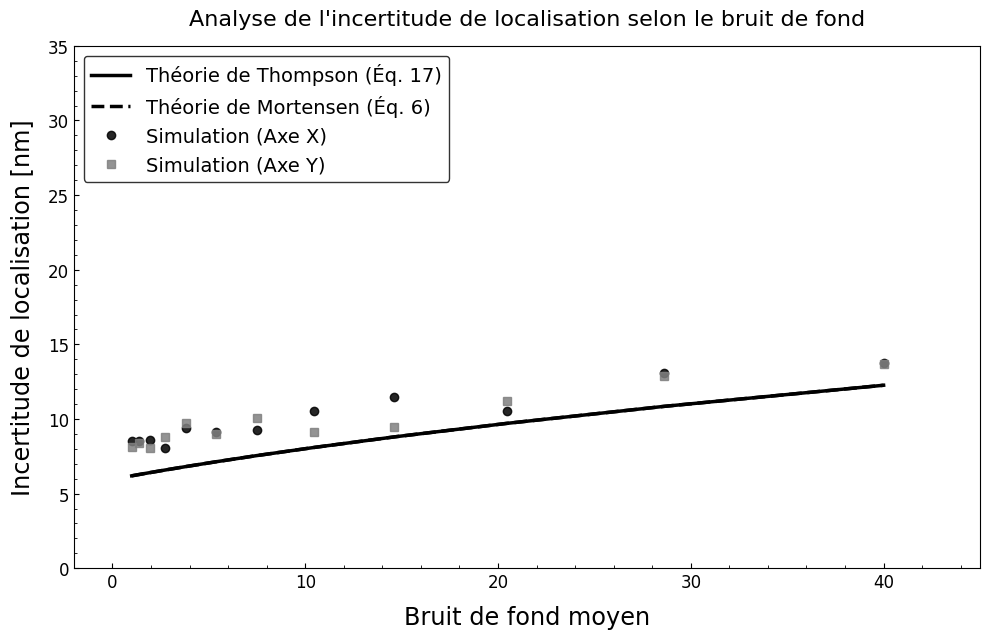

In [43]:
# Définition des paramètres physiques réels
x0_true, y0_true = 25.0, -25.0    # Décentrage sub-pixel réel (nm)
w0_true = 260.0                   # PSF : w0 = 260 nm -> s = 130 nm
a_pixel = 100.0                   # Taille du pixel (nm)
N_photons = 500                   # Flux modéré (photons émis)
grid_size = 15
num_trials = 100                  # 100 répétitions par valeur de bruit

# Valeurs de bruit de fond moyen (B) à tester (photons par pixel)
bg_values = np.logspace(0, np.log10(40), 12)

# Variables de stockage
errors_x = []
errors_y = []
theory_precision = []
theory_precision_6 = []

s_val = w0_true / 2.0             # s = écart-type de la PSF gaussienne
# b_noise = np.sqrt(b_mean)         # b = écart-type du bruit de fond (fluctuation de Poisson)

for B in bg_values:
    trial_errors_x = []
    trial_errors_y = []
    
    # Estimation initiale de l'ajustement
    initial_guess = [0.0, 0.0, w0_true, N_photons, B]
    
    for _ in range(num_trials):
        em = Émetteur(x0=x0_true, y0=y0_true, w0=w0_true, a=a_pixel, N=N_photons, b=B, grid_size=grid_size)
        image_bruitee, X, Y, _ = em.simulation()
        
        try:
            params_fit = em.fit_gaussian_2d(image_bruitee, X, Y, initial_guess)
            trial_errors_x.append(params_fit[0] - x0_true)
            trial_errors_y.append(params_fit[1] - y0_true)
        except:
            continue
            
    # Calcul de la précision de localisation statistique (RMSE)
    rmse_x = np.sqrt(np.mean(np.array(trial_errors_x)**2))
    rmse_y = np.sqrt(np.mean(np.array(trial_errors_y)**2))
    
    errors_x.append(rmse_x)
    errors_y.append(rmse_y)

    theory_precision.append(equation_17(s_val, a_pixel, N_photons, np.sqrt(B)))
    theory_precision_6.append(equation_17(s_val, a_pixel, N_photons, np.sqrt(B)))

    print(f"Fond B = {B:4.1f} ph/px | Err X: {rmse_x:5.2f} nm | Err Y: {rmse_y:5.2f} nm | Théorie: {theory_precision[-1]:5.2f} nm")

# Graphique
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.plot(bg_values, theory_precision, '-', color='black', linewidth=2.5, label='Théorie de Thompson (Éq. 17)')
ax.plot(bg_values, theory_precision_6, '--', color='black', linewidth=2.5, label='Théorie de Mortensen (Éq. 6)')
ax.plot(bg_values, errors_x, 'o', markersize=6, color='black', label='Simulation (Axe X)', alpha=0.85)
ax.plot(bg_values, errors_y, 's', markersize=6, color='gray', label='Simulation (Axe Y)', alpha=0.85)

ax.set_title("Analyse de l'incertitude de localisation selon le bruit de fond", fontsize=16, pad=15)
ax.set_xlabel("Bruit de fond moyen")
ax.set_ylabel("Incertitude de localisation [nm]")
ax.set_xlim(-2, 45)
ax.set_ylim(0, 35)
ax.legend(loc='upper left', fontsize=14)

plt.tight_layout()
plt.show()

Il est possible d'observer que l'incertitude liée à la position n'augmente pas de manière linéaire avec l'augmentation du bruit de fond. Elle suit une courbe de type racine carrée. En analysant mathématiquement l'Équation 17 de Thompson et al. (2002) : 
$$\sigma_x = \sqrt{C_{photon} + C_{fond} \cdot b^2},$$
où $b^2$ (la variance de fluctuation du fond) est directement proportionnelle au bruit de fond moyen $B$ dans une distribution de Poisson. L'incertitude de localisation croît donc comme $\sqrt{B}$. Ainsi, chaque photon de bruit de fond supplémentaire contribue de moins en moins à la dégradation de l'image.

Lorsque le bruit de fond est nul ou extrêmement faible, l'incertitude de position ne descend pas à zéro. Elle semble plutôt se stabiliser sur une valeur minimal d'environ $6\text{ nm}$. Cela s'explique par le fait que la mesure est uniquement limitée par le bruit de photons provenant de l'émetteur même. La précision de localisation est alors donnée par la limite de l'Équation 6 : 
$$\sigma_{x} = \sqrt{\frac{s^2 + a^2/12}{N}} = \sqrt{\frac{130^2 + 100^2/12}{500}} \approx 5,96\text{ nm}.$$

Dès que le fond moyen dépasse 10 photons par pixel, le second terme de l'Équation 17 devient prédominant. L'incertitude de position augmente pour atteindre $14\text{ nm}$ pour un fond de 40 photons/pixel. Le bruit de fond moyen introduit des fluctuations aléatoires d'intensité sur chaque pixel. Ces fluctuations déforment la distribution de la PSF et rendent l'identification du centroïde difficile. Dans ce régime, la précision est proportionnelle à la quantité de bruit de fond et inversement proportionnelle au nombre de photons émis ($\sigma \propto b/N$).

Finalement, l'influence du bruit de fond est amplifiée par les paramètres géométriques du microscope. En effet, dans l'équation 17, le terme correspondant au bruit de fond s'écrit : 
$$\frac{8\pi s^4 b^2}{a^2 N^2}.$$
La largeur de la PSF ($s$) dépend de $s^4$. Ainsi, si la PSF s'élargit légèrement, la sensibilité de la mesure face au bruit de fond sera multipliée par une puissance 4 augmentant grandement sa contribution.

### c) Le rapport entre le rayon de la PSF et la taille du pixel

Début de l'analyse Monte Carlo pour le rapport a/s...


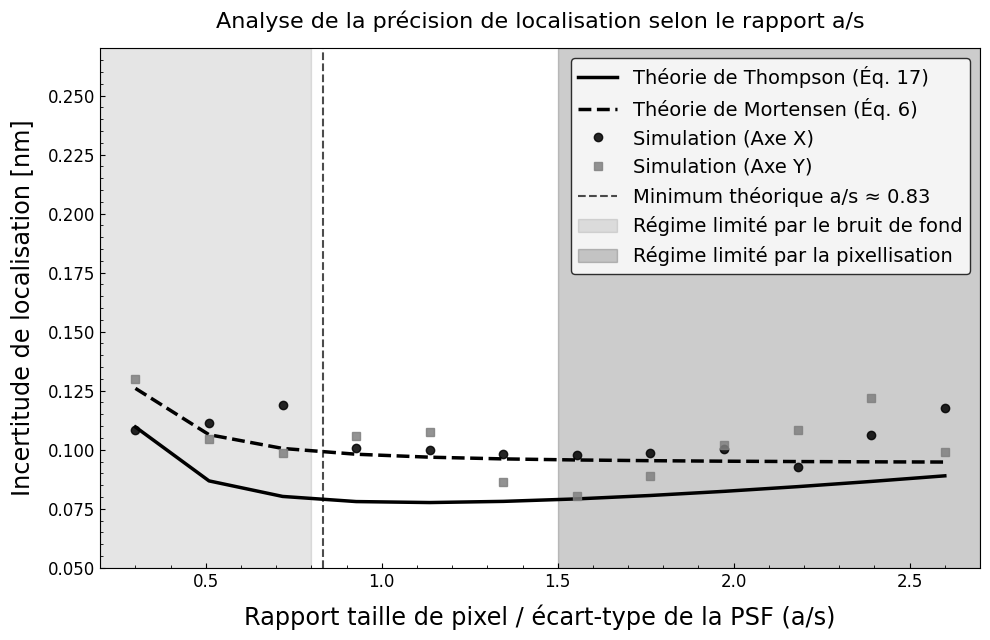

In [44]:
# Définition des paramètres physiques réels
x0_true, y0_true = 15.0, -10.0     # Décentrage sub-pixel (nm)
w0_true = 200.0                    # PSF : w0 = 200 nm -> s = 100 nm
N_photons = 200                    # Nombre modéré de photons
b_mean = 1.0                       # Fond moyen par pixel
grid_size = 21                     # Grille large pour éviter la troncature
num_trials = 100                   # Nombre de tirs statistiques

s_val = w0_true / 2.0              # s = 100 nm

# Échantillonnage du rapport a/s de 0.3 à 2.6
ratios = np.linspace(0.3, 2.6, 12)  
pixel_sizes = ratios * s_val  

errors_x = []
errors_y = []
theory_precision = []
theory_precision_6 = []

print("Début de l'analyse Monte Carlo pour le rapport a/s...")

for a in pixel_sizes:
    trial_errors_x = []
    trial_errors_y = []
    initial_guess = [0.0, 0.0, w0_true, N_photons, b_mean]
    
    for _ in range(num_trials):
        em = Émetteur(x0=x0_true, y0=y0_true, w0=w0_true, a=a, N=N_photons, b=b_mean, grid_size=grid_size)
        image_bruitee, X, Y, _ = em.simulation()
        
        try:
            params_fit = em.fit_gaussian_2d(image_bruitee, X, Y, initial_guess)
            trial_errors_x.append(params_fit[0] - x0_true)
            trial_errors_y.append(params_fit[1] - y0_true)
        except:
            continue
            
    rmse_x = np.sqrt(np.mean(np.array(trial_errors_x)**2))
    rmse_y = np.sqrt(np.mean(np.array(trial_errors_y)**2))
    errors_x.append(rmse_x)
    errors_y.append(rmse_y)

    theory_precision.append(equation_17(s_val, a, N_photons, b_mean))
    theory_precision_6.append(equation_6(s_val, a, N_photons, b_mean))

# Graphique
fig, ax = plt.subplots(figsize=(10, 6.5))

# Affichage normalisé en unités de "taille de spot s" (RMSE / s)
ax.plot(ratios, np.array(theory_precision) / s_val, '-', color='black', linewidth=2.5, label='Théorie de Thompson (Éq. 17)')
ax.plot(ratios, np.array(theory_precision_6) / s_val, '--', color='black', linewidth=2.5, label='Théorie de Mortensen (Éq. 6)')
ax.plot(ratios, np.array(errors_x) / s_val, 'o', color='black', markersize=6, label='Simulation (Axe X)', alpha=0.85)
ax.plot(ratios, np.array(errors_y) / s_val, 's', color='gray', markersize=6, label='Simulation (Axe Y)', alpha=0.85)

# Indication du minimum physique optimal
opt_ratio_theory = (96.0 * b_mean / N_photons)**0.25
ax.axvline(opt_ratio_theory, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Minimum théorique a/s ≈ {opt_ratio_theory:.2f}')

# Zones
ax.axvspan(0.2, 0.8, color='black', alpha=0.1, label='Régime limité par le bruit de fond')
ax.axvspan(1.5, 2.7, color='black', alpha=0.2, label='Régime limité par la pixellisation')

ax.set_title("Analyse de la précision de localisation selon le rapport a/s", fontsize=16, pad=15)
ax.set_xlabel("Rapport taille de pixel / écart-type de la PSF (a/s)")
ax.set_ylabel("Incertitude de localisation [nm]")
ax.legend(loc='upper right', fontsize=14)
ax.set_xlim(0.2, 2.7)
ax.set_ylim(0.05, 0.27)

plt.tight_layout()
plt.show()

La précision de localisation bidimensionnelle est dictée par l'équation de Thompson (Éq. 17) : 
$$\sigma_x^2 = \frac{s^2 + \frac{a^2}{12}}{N} + \frac{8 \pi s^4 b^2}{a^2 N^2}.$$
Cette formule montre que l'incertitude est la somme de deux contributions qui réagissent de manière opposée à la taille du pixel $a$.

Lorsque les pixels sont extrêmement petits par rapport à la PSF ($a/s \ll 1$), la lumière de l'émetteur s'étale sur un très grand nombre de pixels. Le bruit de fond moyen ($b$) est une propriété intrinsèque liée à la surface de détection. En étalant le spot sur une trop grande surface, chaque pixel supplémentaire apporte sa propre contribution de bruit de fond alors qu'il ne reçoit presque aucun photon de signal. Le rapport signal sur bruit local devient très faible. L'incertitude de position augmente beaucoup à cause du terme de bruit de fond qui diverge en $\propto \frac{1}{a^2}$

À l'inverse, lorsque les pixels sont très grands ($a/s \gg 1$), le spot lumineux de l'émetteur est capturé en quasi-totalité par un seul pixel (ou un très petit groupe de pixels). Pour localiser une molécule à l'échelle nanométrique, l'algorithme d'ajustement a besoin d'analyser le gradient de lumière réparti sur plusieurs pixels voisins. Si toute la lumière tombe dans le même pixel, cette information spatiale est définitivement perdue. L'erreur de localisation devient dépendant du bruit de pixellisation seulement suivant $\frac{a}{\sqrt{12}}$.

L'équilibre entre la perte de signal dans le bruit de fond (petits pixels) et la perte de résolution spatiale (grands pixels) crée un minimum. Pour la grande majorité des expériences biologiques pratiques, la taille optimale du pixel doit être environ égale à l'écart-type de la PSF ($a \approx s$), soit un rapport $a/s \approx 1$. Thompson et al. démontrent que la position exacte de ce minimum dépend du budget de photons ($N$) et du bruit de fond ($b$) selon la relation : 
$$\left(\frac{a}{s}\right)^4 \approx \frac{96 b^2}{N}.$$
Si la molécule est très brillante (grand $N$), il est possinle d'utiliser des pixels légèrement plus petits pour mieux échantillonner la forme de la PSF sans être pénalisé par le bruit de fond. Si l'échantillon est très bruité (grand $b$), il est nécessaire d'augmenter la taille des pixels pour collecter plus de photons de signal par pixel et ainsi compenser le bruit de lecture de la caméra.

## Question 3
<!-- Développez un simulateur de 2 émetteurs dans lequel vous pouvez faire varier le rayon $e^{-2}$ de la PSF, la taille des pixels de la caméra (au plan de l’objet), l'intensité de l'émetteur, le bruit de fond et la distance entre les deux. Montrez avec des exemples appropriés que votre simulateur fonctionne. -->


La méthode `simuler_paire_emetteurs` simule l'image de deux émetteurs séparés par une distance $d$. Dans un premier temps, elle calcule le profil d'intensité théorique combiné en additionnant les intégrales analytiques 2D des fonctions d'étalement du point (PSF) de chaque émetteur sur la grille de pixels. Le bruit de fond moyen $b$ est ensuite additionné pour former la carte d'intensité moyenne attendue. Enfin, les fluctuations quantiques de détection sont modélisées en effectuant un tirage aléatoire selon une loi de Poisson sur chaque pixel.

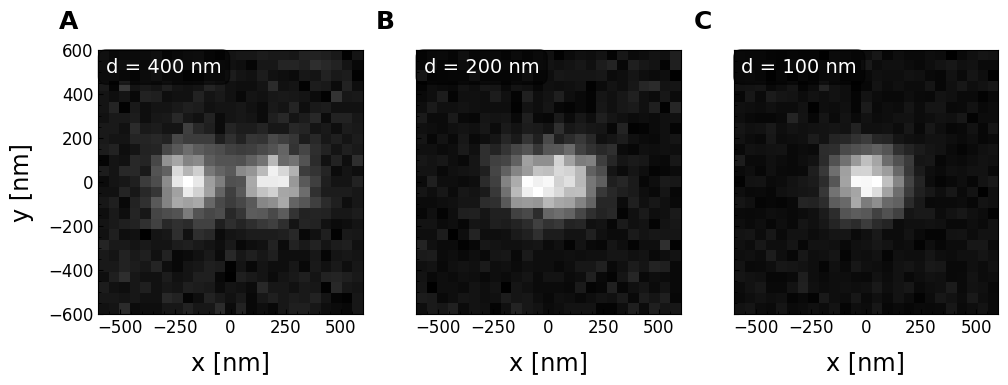

In [188]:
distances = [400, 200, 100]

fig, axes = plt.subplots(1, len(distances), figsize=(12, 4), sharey=True)
s = 0

for ax, d in zip(axes, distances):
    img, X, Y = Émetteur.simuler_paire(distance=d, w0=200, a=50, N=2000, b=10)
    
    half_grid = (X.max() - X.min()) / 2.0
    ax.imshow(img, cmap="gray", extent=[-half_grid, half_grid, -half_grid, half_grid])
    ax.text(0.03, 0.97, f"d = {d} nm", transform=ax.transAxes, fontsize=14, color="white",
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.5))
    ax.text(-0.15, 1.15, f"{string.ascii_uppercase[s]}", transform=ax.transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")
    ax.set_xlabel("x [nm]")
    s += 1

axes[0].set_ylabel("y [nm]")

# plt.tight_layout()
plt.show()

La figure ci-dessus valide le comportement du simulateur de paires d'émetteurs pour différentes distances de séparation. En A ($d = 400\text{ nm}$), la distance entre les deux fluorophores est supérieure à la limite de diffraction ($\sim 200\text{ nm}$). Les deux taches de diffraction (PSF) sont clairement séparées et distinctes à l'œil nu. En B ($d = 200\text{ nm}$), la séparation correspond au cas limite de la résolution optique (critère de Rayleigh / limite d'Abbe). Les deux pics se chevauchent significativement, il devient difficile de séparer visuellement les émetteurs et l'on observe plutôt une unique tache élargie. En C ($d = 100\text{ nm}$), la superposition des profils d'intensité est presque totale. Il n'est physiquement pas possible de distinguer la présence de deux émetteurs à l'œil nu en imagerie conventionnelle.

## Question 4
<!-- En utilisant le simulateur à deux émetteurs, concevez une expérience pour étudier la capacité à distinguer deux émetteurs en fonction du rapport signal/bruit pour les ensembles de paramètres suivants :

a) Pixel size = 0.05 µm & PSF $e^{-2}$ radius = to 0.2 µm et distance entre les émetteurs de 400 nm.

b) Pixel size = 0.05 µm & PSF $e^{-2}$ radius = to 0.2 µm et distance entre les émetteurs de 200 nm. 

c) Pixel size = 0.05 µm & PSF $e^{-2}$ radius = to 0.2 µm et distance entre les émetteurs de 100 nm. -->

La méthode `fit_deux_emetteurs` réalise la déconvolution et la super-localisation des deux molécules par ajustement non linéaire (moindres carrés). À partir de l'image bruitée, elle optimise simultanément les paramètres physiques libres du système, soit les coordonnées spatiales des deux centres $(x_1, y_1)$ et $(x_2, y_2)$, le nombre de photons émis par chaque particule ($N_1, N_2$), la largeur de la PSF ($w_0$) et le bruit de fond ($b$). La distance séparant la paire d'émetteurs est ensuite directement extraite par la norme $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$.

Début des simulations de Monte Carlo...

Analyse de la séparation d = 400.0 nm
  N =    31 photons (SNR =   1.3) | Taux de réussite =  79.0%
  N =    47 photons (SNR =   2.0) | Taux de réussite =  82.0%
  N =    71 photons (SNR =   3.0) | Taux de réussite =  93.0%
  N =   108 photons (SNR =   4.4) | Taux de réussite =  98.0%
  N =   163 photons (SNR =   6.3) | Taux de réussite = 100.0%
  N =   247 photons (SNR =   9.0) | Taux de réussite = 100.0%
  N =   372 photons (SNR =  12.6) | Taux de réussite = 100.0%
  N =   562 photons (SNR =  17.2) | Taux de réussite = 100.0%
  N =   848 photons (SNR =  23.1) | Taux de réussite = 100.0%
  N =  1279 photons (SNR =  30.3) | Taux de réussite = 100.0%
  N =  1930 photons (SNR =  39.1) | Taux de réussite = 100.0%
  N =  2912 photons (SNR =  49.8) | Taux de réussite = 100.0%
  N =  4393 photons (SNR =  62.8) | Taux de réussite = 100.0%
  N =  6628 photons (SNR =  78.5) | Taux de réussite = 100.0%
  N = 10000 photons (SNR =  97.6) | Taux de réussite 

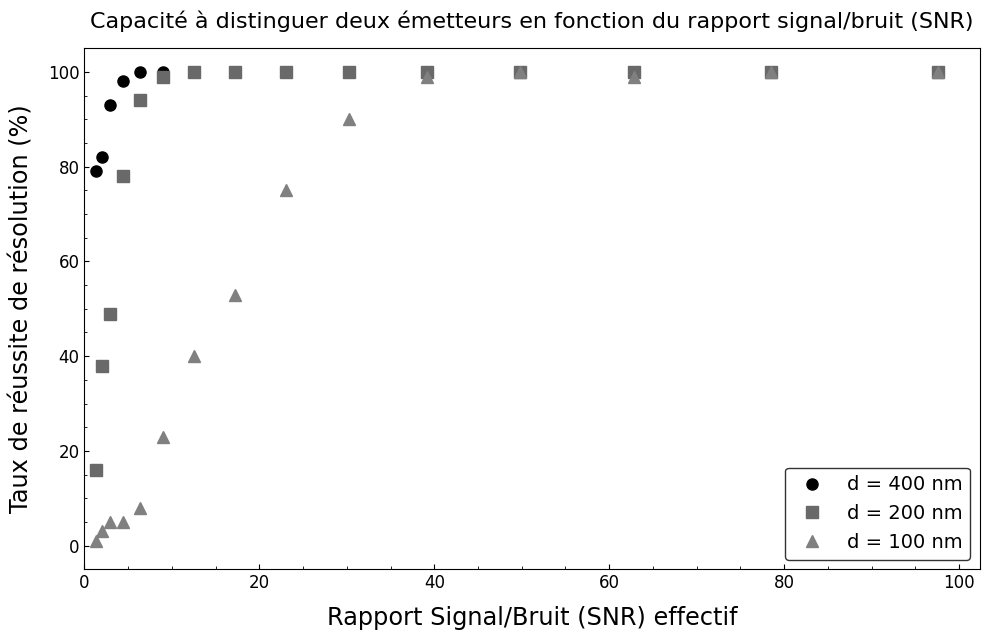

In [189]:
a = 50.0       # nm (Pixel size = 0.05 µm)
w0 = 200.0     # nm (PSF e^-2 radius = 0.2 µm)
b_mean = 10.0  # Bruit de fond moyen (photons/pixel)
grid_size = 25
num_trials = 100

distances = [400.0, 200.0, 100.0]
# Gamme d'intensités testées (variable N)
photon_values = np.logspace(1.5, 4.0, 15, dtype=int)

results = {d: [] for d in distances}

print("Début des simulations de Monte Carlo...")

for d in distances:
    print(f"\nAnalyse de la séparation d = {d} nm")

    for N in photon_values:
        resolved_count = 0
        
        for trial in range(num_trials):
            # Génération dynamique avec l'intensité N courante
            img, X, Y = Émetteur.simuler_paire(distance=d, w0=w0, a=a, N=N, b=b_mean, grid_size=grid_size)

            # Estimation initiale légèrement séparée sur X
            initial_guess = [-d/4.0, 0, N, d/4.0, 0, N, b_mean]
                    
            try:
                fit_res = Émetteur.fit_deux_emetteurs(img, X, Y, a, w0, initial_guess)
                x1_f, y1_f, N1_f, x2_f, y2_f, N2_f, b_f = fit_res
                
                # Évaluation de la résolution
                d_fit = np.sqrt((x1_f - x2_f)**2 + (y1_f - y2_f)**2)
                err_dist = abs(d_fit - d)
                
                # Critères : distance ajustée correcte et intensités significatives
                if err_dist < 0.35 * d and N1_f > 0.25 * N and N2_f > 0.25 * N:
                    resolved_count += 1
            except:
                continue
                
        success_rate = (resolved_count / num_trials) * 100.0
        n_pixels_spot = np.pi * (w0 / a)**2
        snr = N / np.sqrt(N + n_pixels_spot * b_mean)
        
        results[d].append((N, snr, success_rate))
        print(f"  N = {N:5d} photons (SNR = {snr:5.1f}) | Taux de réussite = {success_rate:5.1f}%")

# Graphique
fig, ax = plt.subplots(figsize=(10, 6.5))

markers = {400.0: 'o', 200.0: 's', 100.0: '^'}
colors = {400.0: 'black', 200.0: 'dimgray', 100.0: 'gray'}
labels = {400.0: "d = 400 nm",
        200.0: "d = 200 nm",
        100.0: "d = 100 nm"}

for d in distances:
    data = results[d]
    snrs = [item[1] for item in data]
    rates = [item[2] for item in data]
    ax.plot(snrs, rates, marker=markers[d], linestyle='', markersize=8, linewidth=2.5, label=labels[d], color=colors[d])

ax.set_title("Capacité à distinguer deux émetteurs en fonction du rapport signal/bruit (SNR)", fontsize=16, pad=15)
ax.set_xlabel("Rapport Signal/Bruit (SNR) effectif")
ax.set_ylabel("Taux de réussite de résolution (%)")
ax.set_ylim(-5, 105)
ax.set_xlim(left=0)
ax.legend(loc='lower right', fontsize=14)

plt.tight_layout()
plt.show()


## Question 5
<!-- Discutez de la manière dont, sachant que l'image est constituée de deux émetteurs identiques, on pourrait modifier la fonction d'ajustement ou la photophysique des émetteurs afin d'améliorer les performances. Élaborer une simulation qui permet de résoudre deux particules (Pixel size = 0.05 µm & PSF e-2 radius = to 0.2 µm) avec une distance de 100 nm entre les émetteurs. -->

Il y a les méthodes PALM et STORM. Plutôt que d'imager les deux molécules simultanément, des fluorophores capables de clignoter (blinking) ou des protéines photo-convertibles sont utilisés. En éteignant la grande majorité d'entre eux, on s'assure que pendant une image donnée, un seul émetteur est allumé tandis que son voisin est éteint. Chacun d'eux sont localiés individuellement sur des images successives, puis leurs coordonnées sont superposées pour reconstruire la paire résolue.

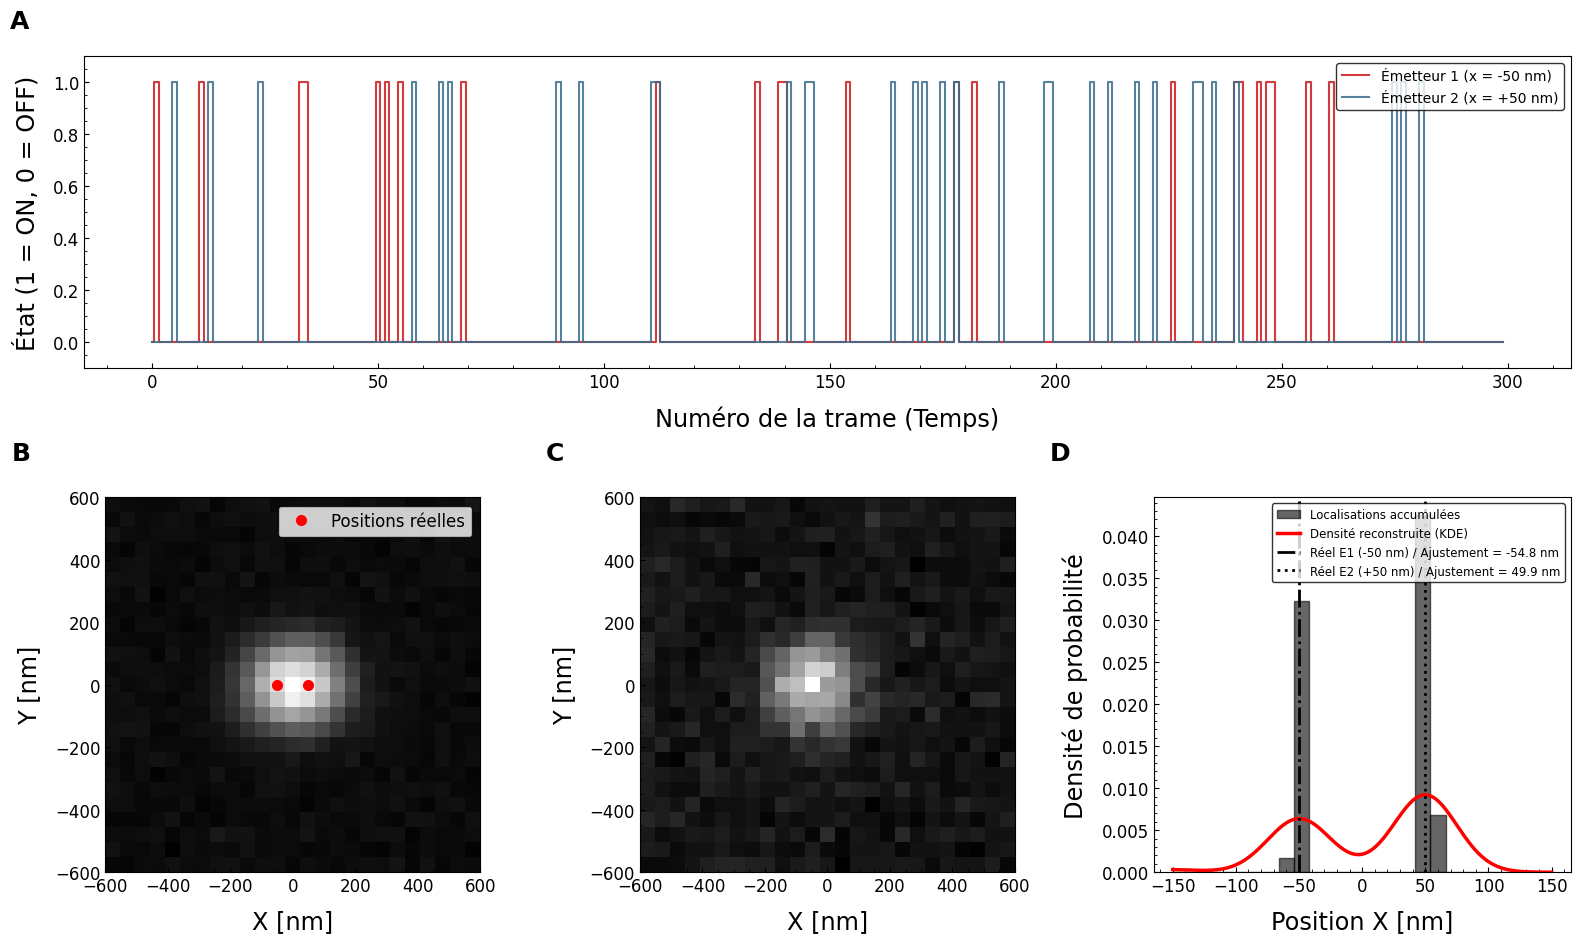

In [206]:
# Expérience de reconstruction super-résolue (SMLM)
distance_reelle = 100.0
a = 50.0          # nm (Pixel size = 0.05 µm)
w0 = 200.0        # nm (PSF e^-2 radius = 0.2 µm)
N_photons = 2000  # Photons émis par molécule quand ON
b_mean = 10.0     # Bruit de fond moyen (photons/pixel)
num_frames = 300  # Nombre de trames dans la série temporelle
p_on = 0.08       # Probabilité d'activation par trame (faible densité)

# Simulation du film
frames, states_e1, states_e2, X, Y, em_template = Émetteur.simuler_film_blinking(
    distance=distance_reelle, num_frames=num_frames, p_on=p_on,
    w0=w0, a=a, N=N_photons, b=b_mean, grid_size=25, seed=42)

# Localisation trame par trame d'émetteurs isolés
localizations_x = []
localizations_y = []

for t in range(num_frames):
    img = frames[t]
    max_val = np.max(img)
    
    # Seuil de détection au-dessus du fond
    if max_val > b_mean + 3 * np.sqrt(b_mean):
        max_idx = np.unravel_index(np.argmax(img), img.shape)
        x_guess, y_guess = X[max_idx], Y[max_idx]
        
        # Ajustement d'une seule Gaussienne
        res = em_template.fit_gaussian_2d(img, X, Y, initial_guess=[x_guess, y_guess, w0, N_photons, b_mean])
        x_fit, y_f, w_f, N_f, b_f = res
        
        # Filtre sur les événements isolés
        if abs(x_fit) < 200 and abs(y_f) < 200 and 0.4 * N_photons < N_f < 1.6 * N_photons:
            localizations_x.append(x_fit)
            localizations_y.append(y_f)

localizations_x = np.array(localizations_x)
e1_fits = localizations_x[localizations_x < 0]
e2_fits = localizations_x[localizations_x > 0]
mean_e1 = np.mean(e1_fits)
mean_e2 = np.mean(e2_fits)
d_mesuree = mean_e2 - mean_e1

# graphique
fig = plt.figure(figsize=(16, 9.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2])

# Panneau 1 : visualisation duclignotement
ax1 = fig.add_subplot(gs[0, :])
frames_idx = np.arange(num_frames)
ax1.step(frames_idx, states_e1 * 1.0, color="#cb1818", where='mid', label='Émetteur 1 (x = -50 nm)', alpha=0.85, linewidth=1.5)
ax1.step(frames_idx, states_e2 * 1.0, color="#396c8a", linestyle= '-', where='mid', label='Émetteur 2 (x = +50 nm)', alpha=0.85, linewidth=1.5)
# ax1.set_title("Visualisation temporelle des états d'émission (Clignotement stochastique / Blinking)", fontsize=16, pad=10)
ax1.set_xlabel("Numéro de la trame (Temps)")
ax1.set_ylabel("État (1 = ON, 0 = OFF)")
ax1.set_ylim(-0.1, 1.1)
# ax1.set_yticks([3])
# ax1.set_yticks([0, 1])
ax1.legend(loc='upper right', fontsize=10)
ax1.text(-0.05, 1.15, f"{string.ascii_uppercase[0]}", transform=ax1.transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

# Panneau 2 : Image Champ Large Cumulée
ax2 = fig.add_subplot(gs[1, 0])
sum_img = np.sum(frames, axis=0)
extent = [X.min(), X.max(), Y.min(), Y.max()]
im2 = ax2.imshow(sum_img, extent=extent, cmap='gray', origin='lower')
# ax2.set_title("Somme de toutes les trames (Champ Large)", fontsize=11, pad=10)
ax2.set_xlabel("X [nm]")
ax2.set_ylabel("Y [nm]")
# ax2.axis('off')
ax2.plot([-50, 50], [0,0], 'ro', markersize=6, markeredgewidth=2, label='Positions réelles')
ax2.legend(loc='upper right', fontsize=12)
ax2.text(-0.25, 1.15, f"{string.ascii_uppercase[1]}", transform=ax2.transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

# Panneau 3 : Trame individuelle
ax3 = fig.add_subplot(gs[1, 1])

single_on_candidates = np.where((states_e1 == 1) & (states_e2 == 0))[0]
single_on_idx = single_on_candidates[4]
im3 = ax3.imshow(frames[single_on_idx], extent=extent, cmap='gray', origin='lower')
# ax3.set_title(f"Trame #{single_on_idx} individuelle (Émetteur 1 SEUL 'ON')\n(PSF isolée)", fontsize=16, pad=10)
ax3.set_xlabel("X [nm]")
ax3.set_ylabel("Y [nm]")
ax3.text(-0.25, 1.15, f"{string.ascii_uppercase[2]}", transform=ax3.transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")
# ax3.axis('off')

# Panneau 4 : Reconstruction Super-Résolue
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(localizations_x, bins=25, range=(-150, 150), color='black', alpha=0.6, edgecolor='black', density=True, label='Localisations accumulées')
kde = gaussian_kde(localizations_x)
x_range = np.linspace(-150, 150, 500)
ax4.plot(x_range, kde(x_range), color='red', linewidth=2.5, label='Densité reconstruite (KDE)')
ax4.axvline(-50, color='black', linestyle='-.', linewidth=2, label=f'Réel E1 (-50 nm) / Ajustement = {mean_e1:.1f} nm')
ax4.axvline(50, color='black', linestyle=':', linewidth=2, label=f'Réel E2 (+50 nm) / Ajustement = {mean_e2:.1f} nm')
ax4.text(-0.25, 1.15, f"{string.ascii_uppercase[3]}", transform=ax4.transAxes, fontsize=18,
        color="black", fontweight="bold", verticalalignment="top")

# ax4.set_title(f"Image Super-Résolue Reconstruite (PALM/STORM)\n(Distance calculée par Blinking = {d_mesuree:.1f} nm)", fontsize=16, pad=10)
ax4.set_xlabel("Position X [nm]")
ax4.set_ylabel("Densité de probabilité")
ax4.legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()

Il est possible de simuler une méthode, `simuler_film_blinking`, de microscopie utilisant le blinking en ajoutant une probabilité d'activation à chaque instant (pour un cas discret comme le notre il s'agit d'une probabilité par trame). Cette simultation utilise une probabilité d'activation $p_{on} = 0,08$. Ainsi, l'émetteur 1 et 2 sont actifs simultanément qu'une faible proportion du temps comme il est possible de visualiser à la sous-figure A. En sommant l'ensemble des trames simulés, nous retrouvons l'image typique observé jusqu'à présent illustrée à la sous-figure B, soit les deux PSF superposé formant une tache lumineuse unique. La limite de diffraction empêche la distinction précise des deux émetteurs pour une distance de 100 nm. 

En observant une trame individuelle (par exemple la trame #50 sur la sous-figure C), l'émetteur 1 est seul à émettre. Sa PSF est nette, ce qui permet à l'algorithme d'ajustement simple fit_gaussian_2d, le même qu'utilisé pour la présence d'un émetteur seul, de déterminer son centroìde avec précision.

L'accumulation de 50 événements pour lesquels un seul émetteur est actifs à la fois fait apparaître deux pics distincts sur l'histogramme de la sous-figure D. Les positions moyennes calculées sont $x = -54,8\text{ nm}$ pour l'émetteur 1 dont la valeur réelle est $-50,0\text{ nm}$ et $x = +49,9\text{ nm}$ pour l'émetteur 2 dont la valeur réelle est $+50,0\text{ nm}$. La distance mesurée à l'aide de cette méthode est alors $d = 104,7\text{ nm}$, représentant un écart relatif de 4,74\%.

### Références

R. E. Thompson, D. R. Larson, and W. W. Webb, "Precise Nanometer Localization Analysis for Individual Fluorescent Probes," Biophys. J., vol. 82, no. 5, pp. 2775–2783, 2002.

K. I. Mortensen, L. S. Churchman, J. A. Spudich, and H. Flyvbjerg, "Optimized localization analysis for single-molecule tracking and superresolution microscopy," Nat. Methods, vol. 7, no. 5, pp. 377–381, 2010.

A. Godin, "BPH-7009 Analyse de signaux - Cours 1: Microscopies, détecteurs et super-localisation," Université Laval, 2026.